In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Rutas relativas al directorio raíz del proyecto
BASE_DIR = Path('../../').resolve()
DATOS_LIMPIOS = BASE_DIR / "Datos" / "Datos_limpios_activos"

carreras = ["Matemáticas", "Física"]

Generando matriz de correlación para: Matemáticas


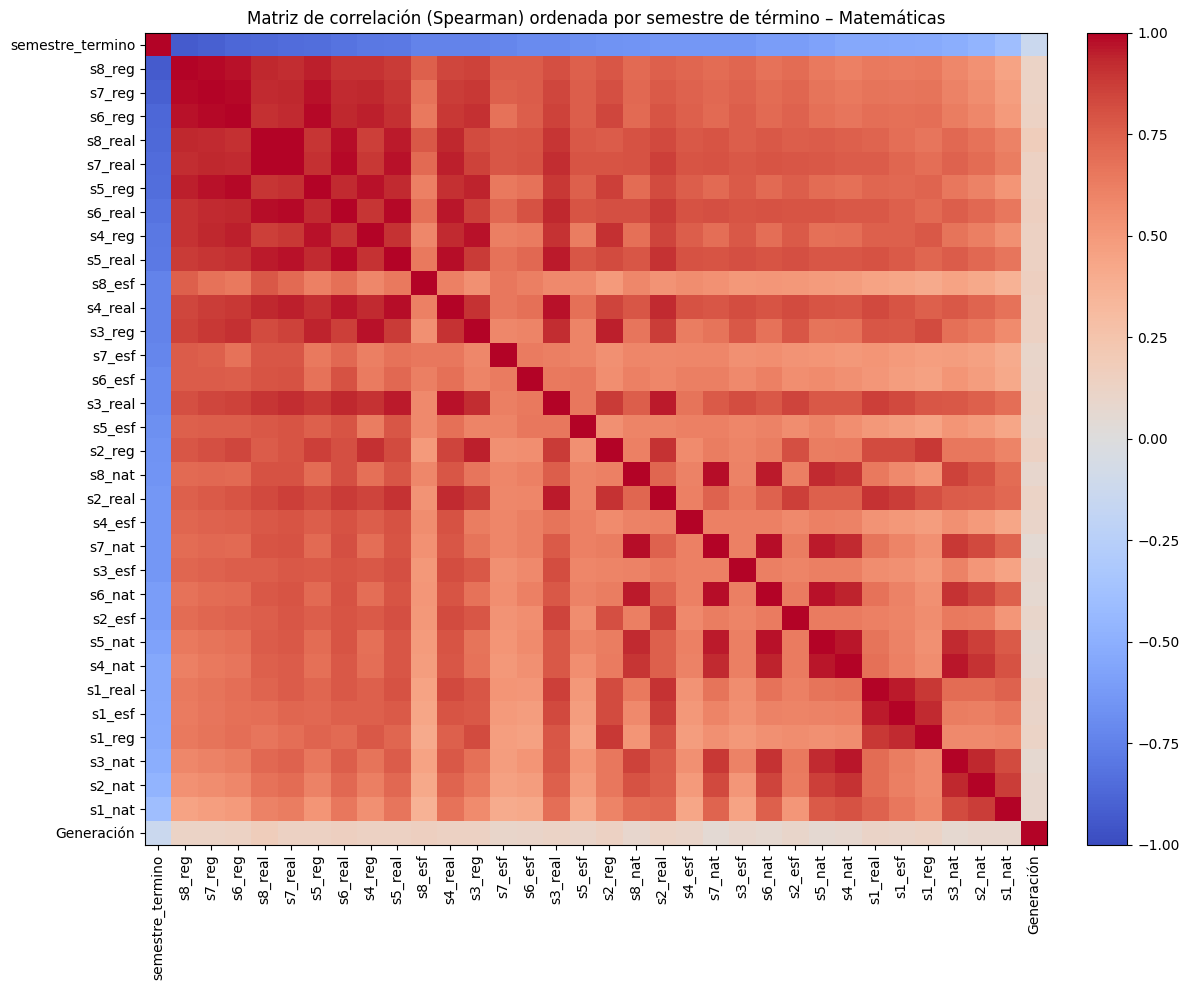

Generando matriz de correlación para: Física


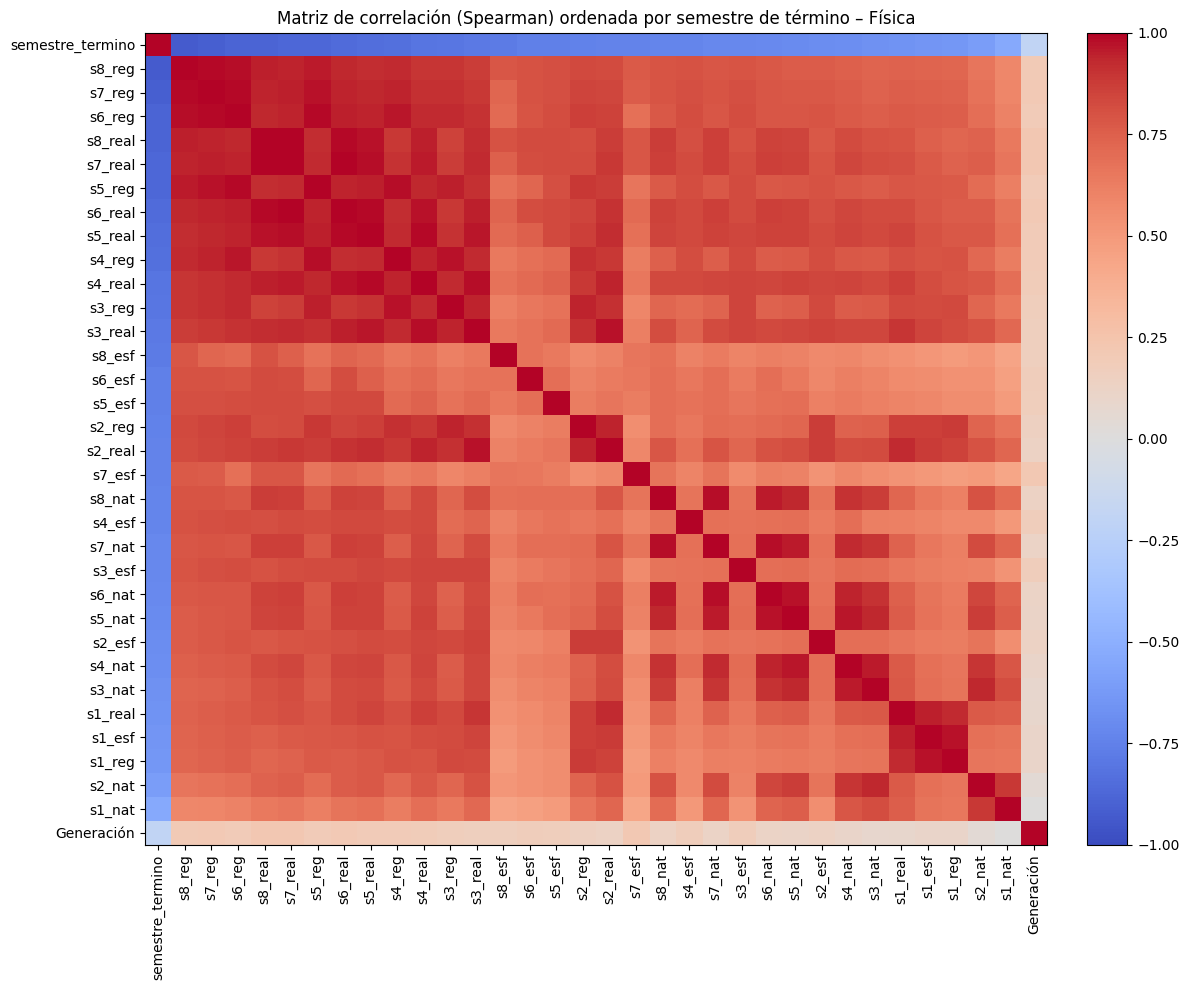

In [2]:
for carrera in carreras:
    print(f"Generando matriz de correlación para: {carrera}")
    archivo = DATOS_LIMPIOS / f"{carrera}.xlsx"
    
    if not archivo.exists():
        print(f"Archivo no encontrado: {archivo}")
        continue

    df = pd.read_excel(archivo)

    cols_num = (
        ["semestre_termino", "Generación"] +
        [c for c in df.columns if c.startswith("s") and c != "semestre_termino"]
    )
    
    # Filtrar columnas que realmente existen
    cols_num = [c for c in cols_num if c in df.columns]

    df_num = df[cols_num]

    # Calcular correlación de Spearman
    corr = df_num.corr(method="spearman")
    corr.index.name = None

    # Ordenar variables por correlación absoluta con el semestre de término
    serie_obj = corr.filter(regex="^semestre_termino$").iloc[:, 0]

    orden = (
        serie_obj
        .astype(float)
        .abs()
        .sort_values(ascending=False)
        .index
    )

    corr_ord = corr.loc[orden, orden]

    # Visualización
    plt.figure(figsize=(12, 10))
    im = plt.imshow(corr_ord, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(
        ticks=np.arange(len(corr_ord.columns)),
        labels=corr_ord.columns,
        rotation=90
    )

    plt.yticks(
        ticks=np.arange(len(corr_ord.index)),
        labels=corr_ord.index
    )

    plt.title(f"Matriz de correlación (Spearman) ordenada por semestre de término – {carrera}")
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'imagenes' / f'heatmap_{carrera.lower().replace("á", "a").replace("í", "i")}.png', dpi=300, bbox_inches='tight')
    plt.show()